In [1]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np

In [3]:
class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()
 
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [5]:
def set_seed(seed):
    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

In [6]:
def evaluate(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total
 


In [7]:
DATASET_NAME ='KMNIST'
DATASET_CLASS = torchvision.datasets.KMNIST
NORMALIZE_MEAN_STD = ((0.1918,),(0.3483))
SEEDS =[0,42,123]

In [8]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*NORMALIZE_MEAN_STD)
])
train_data = DATASET_CLASS(root='./data', train=True, download=True, transform=transform)
test_data  = DATASET_CLASS(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)
print(f"Train size: {len(train_data)}")
print(f"Test size: {len(test_data)}")

Train size: 60000
Test size: 10000


In [16]:
for seed in SEEDS:
    print(f"\n=== Training {DATASET_NAME} seed {seed} ===")
    set_seed(seed)
    train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
    model=TinyNet()
    optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(5):
        total_loss = 0 
        for images, labels in train_loader:
            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output,labels)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        print(f"  Epoch {epoch+1} | Loss: {total_loss/len(train_loader):.4f}")
    baseline_acc = evaluate(model,test_loader)
    print(f"  Seed {seed} baseline accuracy: {baseline_acc:.2f}%")
    
    fname = f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'
    torch.save(model.state_dict(), fname)
    print(f"  Saved: {fname}")


=== Training KMNIST seed 0 ===
  Epoch 1 | Loss: 0.4479
  Epoch 2 | Loss: 0.1632
  Epoch 3 | Loss: 0.1111
  Epoch 4 | Loss: 0.0813
  Epoch 5 | Loss: 0.0628
  Seed 0 baseline accuracy: 92.86%
  Saved: tinynet_kmnist_seed0.pth

=== Training KMNIST seed 42 ===
  Epoch 1 | Loss: 0.3892
  Epoch 2 | Loss: 0.1328
  Epoch 3 | Loss: 0.0877
  Epoch 4 | Loss: 0.0641
  Epoch 5 | Loss: 0.0507
  Seed 42 baseline accuracy: 93.63%
  Saved: tinynet_kmnist_seed42.pth

=== Training KMNIST seed 123 ===
  Epoch 1 | Loss: 0.3716
  Epoch 2 | Loss: 0.1298
  Epoch 3 | Loss: 0.0852
  Epoch 4 | Loss: 0.0628
  Epoch 5 | Loss: 0.0480
  Seed 123 baseline accuracy: 92.74%
  Saved: tinynet_kmnist_seed123.pth


In [10]:
def load_fresh_model(seed):
    model = TinyNet()
    model.load_state_dict(torch.load(f'tinynet_{DATASET_NAME.lower()}_seed{seed}.pth'))
    model.eval()
    return model
 
def prune_single_layer(model, layer_name, amount):
    layer = getattr(model, layer_name)
    prune.l1_unstructured(layer, name='weight', amount=amount)
    return model

In [13]:


LAYERS = ['conv1', 'conv2', 'fc1', 'fc2']
CHECKPOINTS_FINE = list(range(20, 81))
results = {}
per_layer_results = {}
for seed in SEEDS:
    print(f"\n=== Sensitivity sweep, {DATASET_NAME} seed {seed} ===")
    baseline_model = load_fresh_model(seed)
    baseline_acc = evaluate(baseline_model, test_loader)
 
    seed_gaps = {}
    per_layer_results[seed] ={}
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        layer_drops = {}
        for layer_name in LAYERS:
            m = load_fresh_model(seed)
            m = prune_single_layer(m, layer_name, amount)
            acc = evaluate(m, test_loader)
            drop = baseline_acc - acc
            layer_drops[layer_name] = drop
        per_layer_results[seed][pct] = layer_drops
        gap = max(layer_drops.values()) - min(layer_drops.values())
        seed_gaps[pct] = gap
        print(f"  {pct}% sparsity | gap = {gap:.2f}pp | drops = {layer_drops}")
 
    results[seed] = seed_gaps

 


=== Sensitivity sweep, KMNIST seed 0 ===
  20% sparsity | gap = 0.11pp | drops = {'conv1': 0.0799999999999983, 'conv2': 0.14000000000000057, 'fc1': 0.030000000000001137, 'fc2': 0.10999999999999943}
  21% sparsity | gap = 0.11pp | drops = {'conv1': 0.0, 'conv2': 0.09999999999999432, 'fc1': 0.01999999999999602, 'fc2': 0.10999999999999943}
  22% sparsity | gap = 0.11pp | drops = {'conv1': 0.06999999999999318, 'conv2': 0.09999999999999432, 'fc1': -0.010000000000005116, 'fc2': 0.0}
  23% sparsity | gap = 0.05pp | drops = {'conv1': 0.0, 'conv2': 0.04999999999999716, 'fc1': 0.030000000000001137, 'fc2': 0.010000000000005116}
  24% sparsity | gap = 0.14pp | drops = {'conv1': 0.0, 'conv2': 0.14000000000000057, 'fc1': 0.0, 'fc2': 0.04000000000000625}
  25% sparsity | gap = 0.11pp | drops = {'conv1': 0.06999999999999318, 'conv2': 0.04000000000000625, 'fc1': 0.030000000000001137, 'fc2': 0.14000000000000057}
  26% sparsity | gap = 0.12pp | drops = {'conv1': 0.0799999999999983, 'conv2': 0.1299999999

In [14]:
import json

with open('KMIST_gap_20_80.json', 'w') as f:
    json.dump({'results': results, 'per_layer_results': per_layer_results}, f)

print("Saved.")

Saved.


In [15]:
def prune_uniform(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1,   name='weight', amount=amount)
    prune.l1_unstructured(model.fc2,   name='weight', amount=amount)
    return model
 
uniform_results = {}
 
for seed in SEEDS:
    print(f"\n=== Uniform pruning sweep, {DATASET_NAME} seed {seed} ===")
    seed_accs = {}
    for pct in CHECKPOINTS_FINE:
        amount = pct / 100
        m = load_fresh_model(seed)
        m = prune_uniform(m, amount)
        acc = evaluate(m, test_loader)
        seed_accs[pct] = acc
        print(f"  {pct}% sparsity | accuracy = {acc:.2f}%")
    uniform_results[seed] = seed_accs
 
print(f"\n\n=== SUMMARY: {DATASET_NAME} accuracy under uniform pruning, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{uniform_results[seed][pct]:>12.2f}", end="")
    print()


=== Uniform pruning sweep, KMNIST seed 0 ===
  20% sparsity | accuracy = 92.47%
  21% sparsity | accuracy = 92.62%
  22% sparsity | accuracy = 92.58%
  23% sparsity | accuracy = 92.76%
  24% sparsity | accuracy = 92.67%
  25% sparsity | accuracy = 92.69%
  26% sparsity | accuracy = 92.59%
  27% sparsity | accuracy = 92.66%
  28% sparsity | accuracy = 92.56%
  29% sparsity | accuracy = 92.66%
  30% sparsity | accuracy = 92.63%
  31% sparsity | accuracy = 92.63%
  32% sparsity | accuracy = 92.63%
  33% sparsity | accuracy = 92.46%
  34% sparsity | accuracy = 92.36%
  35% sparsity | accuracy = 92.27%
  36% sparsity | accuracy = 92.30%
  37% sparsity | accuracy = 92.20%
  38% sparsity | accuracy = 92.20%
  39% sparsity | accuracy = 92.03%
  40% sparsity | accuracy = 91.80%
  41% sparsity | accuracy = 91.56%
  42% sparsity | accuracy = 91.23%
  43% sparsity | accuracy = 90.08%
  44% sparsity | accuracy = 88.57%
  45% sparsity | accuracy = 88.52%
  46% sparsity | accuracy = 88.36%
  47% spa

In [17]:
print(f"\n\n=== SUMMARY: {DATASET_NAME} gap by sparsity, across seeds ===")
print(f"{'Sparsity':>10}", end="")
for seed in SEEDS:
    print(f"{'seed'+str(seed):>12}", end="")
print()
 
for pct in CHECKPOINTS_FINE:
    print(f"{pct:>9}%", end="")
    for seed in SEEDS:
        print(f"{results[seed][pct]:>12.2f}", end="")
    print()
 
import json
outname = f'{DATASET_NAME.lower()}_multiseed_results.json'
with open(outname, 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSaved: {outname}")



=== SUMMARY: KMNIST gap by sparsity, across seeds ===
  Sparsity       seed0      seed42     seed123
       20%        0.11        0.04        0.43
       21%        0.11        0.05        0.49
       22%        0.11        0.05        0.64
       23%        0.05        0.08        0.57
       24%        0.14        0.07        0.59
       25%        0.11        0.11        0.52
       26%        0.12        0.23        0.32
       27%        0.13        0.19        0.40
       28%        0.24        0.24        0.55
       29%        0.20        0.16        0.49
       30%        0.22        0.35        0.49
       31%        0.29        0.62        0.53
       32%        0.29        0.57        0.82
       33%        0.27        0.72        1.01
       34%        0.42        0.75        1.19
       35%        0.29        0.89        0.80
       36%        0.35        0.85        0.84
       37%        0.49        0.91        0.98
       38%        0.47        1.30        1.01
    

# GRAPH

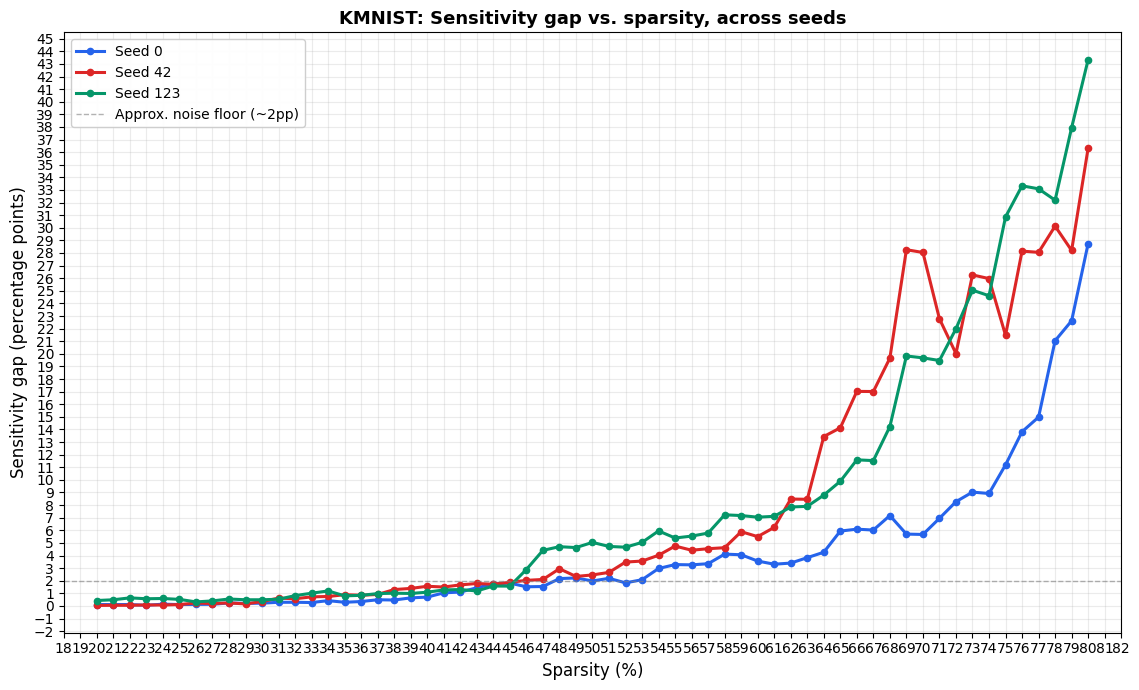

Saved: kmnist_gap_multiseed.png


In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator 

fig, ax = plt.subplots(figsize=(11.5, 7))
 
colors = {0: '#2563EB', 42: '#DC2626', 123: '#059669'}
 
for seed in SEEDS:
    gaps = [results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, gaps, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.axhline(2, color='gray', linestyle='--', linewidth=1, alpha=0.6, label='Approx. noise floor (~2pp)')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Sensitivity gap (percentage points)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Sensitivity gap vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(1))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(1)) 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_gap_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_gap_multiseed.png")

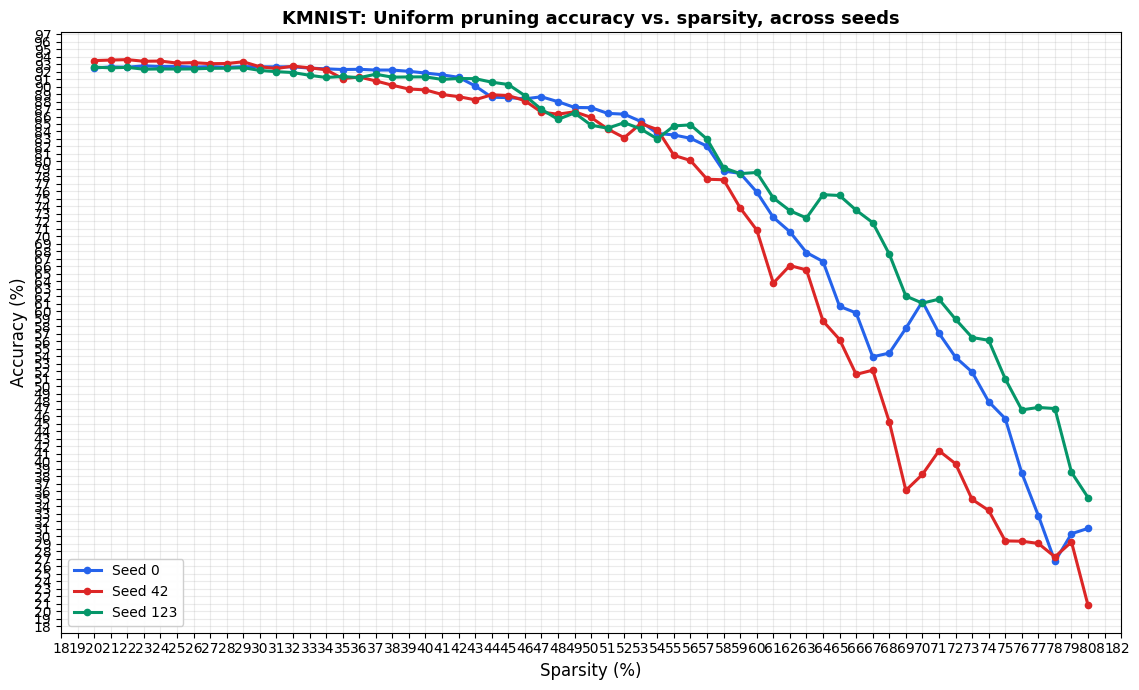

Saved: kmnist_uniform_accuracy_multiseed.png


In [20]:
 
# ============================================================
# GRAPH 2 — Accuracy vs sparsity (uniform pruning), across seeds
# Uses `uniform_results` (from your uniform pruning sweep cell)
# ============================================================
fig, ax = plt.subplots(figsize=(11.5, 7))
 
for seed in SEEDS:
    accs = [uniform_results[seed][pct] for pct in CHECKPOINTS_FINE]
    ax.plot(CHECKPOINTS_FINE, accs, '-o', color=colors.get(seed, 'gray'),
            linewidth=2.2, markersize=4.5, label=f'Seed {seed}')
 
ax.set_xlabel('Sparsity (%)', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'{DATASET_NAME}: Uniform pruning accuracy vs. sparsity, across seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower left', fontsize=10, framealpha=0.95)
ax.grid(True, alpha=0.25)
ax.set_xlim(min(CHECKPOINTS_FINE) - 2, max(CHECKPOINTS_FINE) + 2)
ax.xaxis.set_major_locator(MultipleLocator(1))    # x-axis ticks every 5% instead of every 10%
ax.yaxis.set_major_locator(MultipleLocator(1)) 
plt.tight_layout()
plt.savefig(f'{DATASET_NAME.lower()}_uniform_accuracy_multiseed.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {DATASET_NAME.lower()}_uniform_accuracy_multiseed.png")

In [22]:
import json

with open('KMIST_gap_20_80.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # keys are strings (JSON does this) — seed and pct both

# Count how often each layer is the max-drop (most sensitive) layer, per seed
layer_win_counts = {}

for seed_str, checkpoints in per_layer.items():
    layer_win_counts[seed_str] = {'conv1': 0, 'conv2': 0, 'fc1': 0, 'fc2': 0}
    for pct_str, drops in checkpoints.items():
        max_layer = max(drops, key=drops.get)
        layer_win_counts[seed_str][max_layer] += 1

print("=== How often each layer is the most-sensitive one, out of 21 checkpoints ===")
for seed_str, counts in layer_win_counts.items():
    print(f"Seed {seed_str}: {counts}")

print("\n=== Dominant layer at every single checkpoint (to spot flips) ===")
for seed_str, checkpoints in per_layer.items():
    print(f"\nSeed {seed_str}:")
    for pct_str in sorted(checkpoints, key=lambda x: int(x)):
        drops = checkpoints[pct_str]
        max_layer = max(drops, key=drops.get)
        print(f"  {pct_str}% -> {max_layer} (drop={drops[max_layer]:.2f})")

=== How often each layer is the most-sensitive one, out of 21 checkpoints ===
Seed 0: {'conv1': 19, 'conv2': 38, 'fc1': 0, 'fc2': 4}
Seed 42: {'conv1': 24, 'conv2': 0, 'fc1': 3, 'fc2': 34}
Seed 123: {'conv1': 51, 'conv2': 0, 'fc1': 0, 'fc2': 10}

=== Dominant layer at every single checkpoint (to spot flips) ===

Seed 0:
  20% -> conv2 (drop=0.14)
  21% -> fc2 (drop=0.11)
  22% -> conv2 (drop=0.10)
  23% -> conv2 (drop=0.05)
  24% -> conv2 (drop=0.14)
  25% -> fc2 (drop=0.14)
  26% -> fc2 (drop=0.15)
  27% -> fc2 (drop=0.16)
  28% -> conv1 (drop=0.25)
  29% -> conv1 (drop=0.17)
  30% -> conv2 (drop=0.22)
  31% -> conv2 (drop=0.27)
  32% -> conv2 (drop=0.22)
  33% -> conv1 (drop=0.22)
  34% -> conv2 (drop=0.38)
  35% -> conv2 (drop=0.34)
  36% -> conv2 (drop=0.38)
  37% -> conv2 (drop=0.58)
  38% -> conv2 (drop=0.53)
  39% -> conv2 (drop=0.74)
  40% -> conv2 (drop=0.80)
  41% -> conv2 (drop=1.03)
  42% -> conv2 (drop=1.15)
  43% -> conv2 (drop=1.45)
  44% -> conv2 (drop=1.82)
  45% -> co

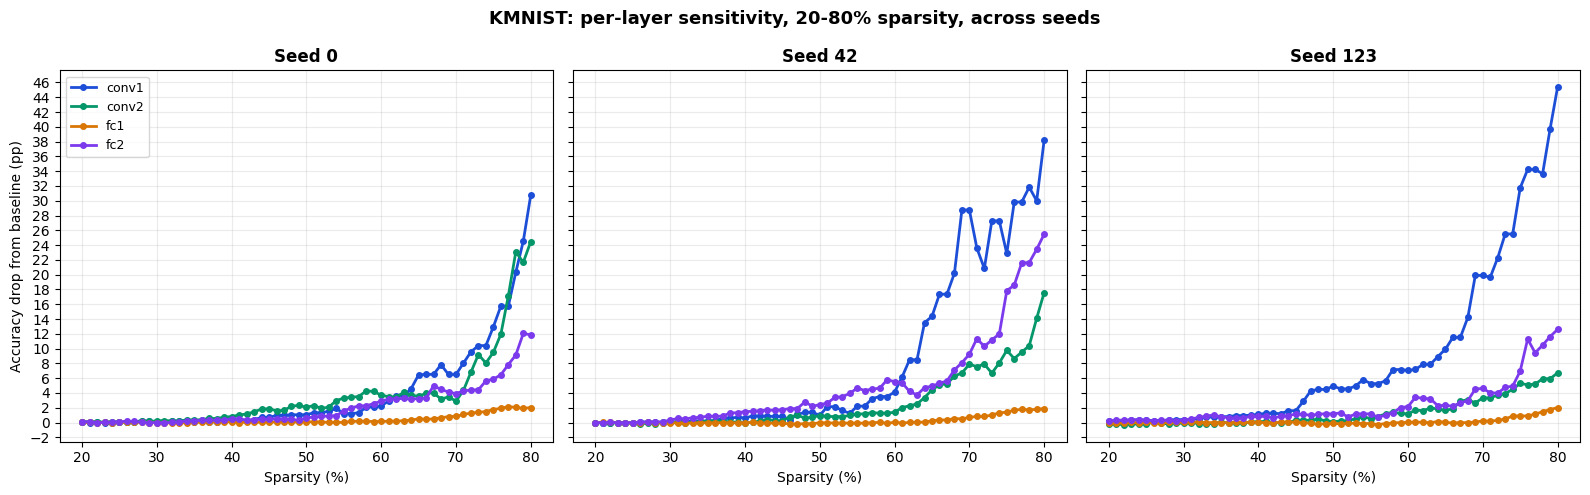

Saved: KMNIST_layer_analysis_20_80.png


In [30]:
import json
import matplotlib.pyplot as plt

with open('KMIST_gap_20_80.json', 'r') as f:
    saved = json.load(f)

per_layer = saved['per_layer_results']  # seed -> pct -> {layer: drop}, all keys are strings after JSON reload

layer_colors = {'conv1': '#1D4ED8', 'conv2': '#059669', 'fc1': '#D97706', 'fc2': '#7C3AED'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, seed in zip(axes, SEEDS):
    seed_str = str(seed)
    checkpoints = sorted(per_layer[seed_str].keys(), key=lambda x: int(x))
    sparsities = [int(pct) for pct in checkpoints]

    for layer_name, color in layer_colors.items():
        drops = [per_layer[seed_str][pct][layer_name] for pct in checkpoints]
        ax.plot(sparsities, drops, '-o', color=color, linewidth=2, markersize=4, label=layer_name)

    ax.set_title(f'Seed {seed}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sparsity (%)')
    ax.grid(True, alpha=0.25)
   
ax.yaxis.set_major_locator(MultipleLocator(2))
axes[0].set_ylabel('Accuracy drop from baseline (pp)')
axes[0].legend(loc='upper left', fontsize=9)
fig.suptitle('KMNIST: per-layer sensitivity, 20-80% sparsity, across seeds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('KMNIST_layer_analysis_20_80.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: KMNIST_layer_analysis_20_80.png")

In [1]:
import json

with open('kmnist_full_sweep.json', 'r') as f:
    saved = json.load(f)

results = saved['results']                  # seed -> pct -> gap
uniform_results = saved['uniform_results']   # seed -> pct -> accuracy

for seed_str in results:
    print(f"\n=== KMNIST, seed {seed_str} ===")
    print(f"{'Sparsity':>10}{'Gap':>10}{'Accuracy':>12}")
    checkpoints = sorted(results[seed_str].keys(), key=lambda x: int(x))
    for pct in checkpoints:
        gap = results[seed_str][pct]
        acc = uniform_results[seed_str][pct]
        print(f"{pct:>9}%{gap:>10.2f}{acc:>12.2f}")

FileNotFoundError: [Errno 2] No such file or directory: 'kmnist_full_sweep.json'